Record 0 → 3970 points


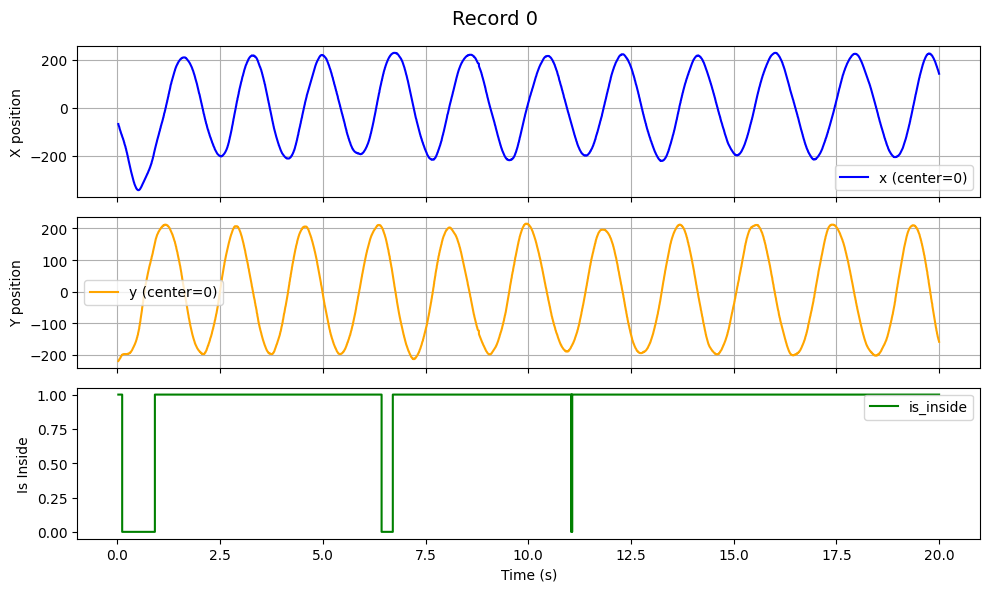

Record 1 → 3897 points


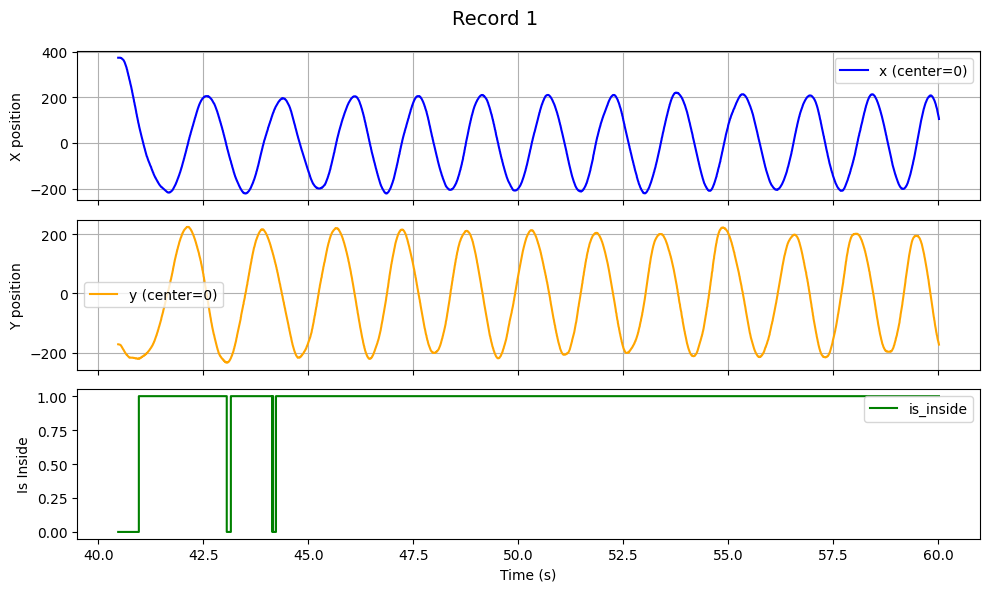

Record 2 → 3897 points


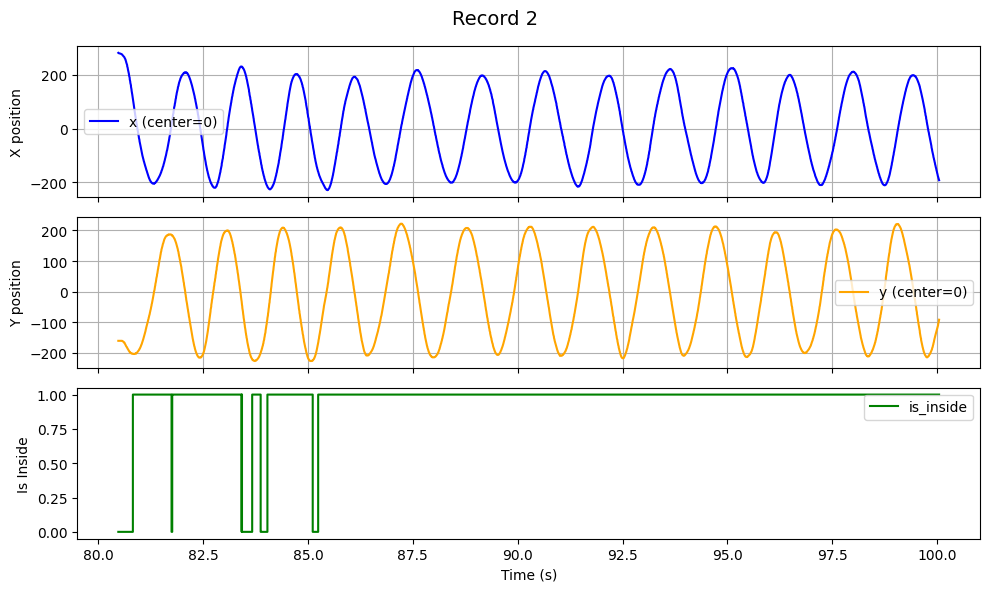

Record 3 → 3883 points


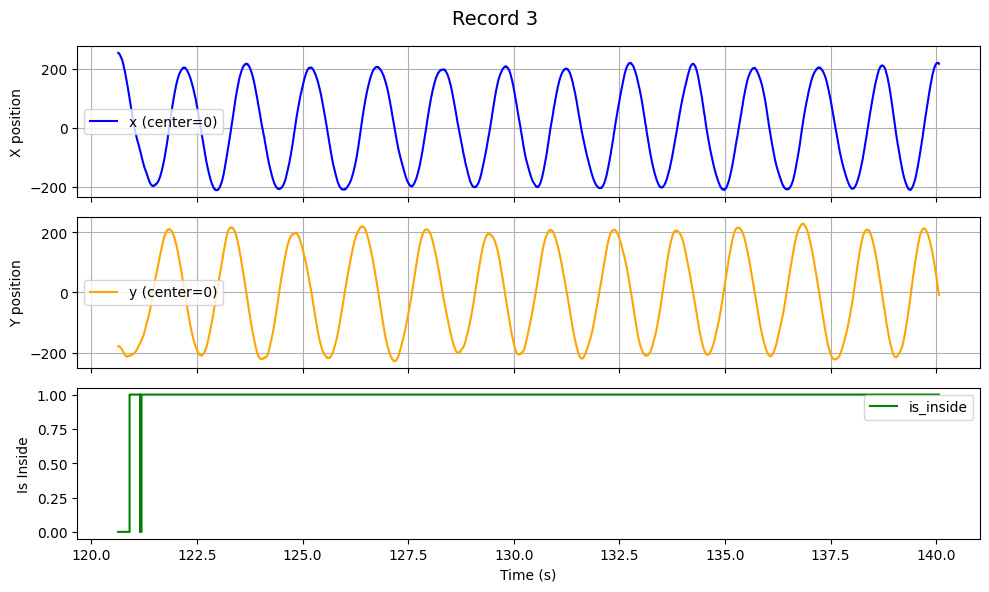

Record 4 → 3935 points


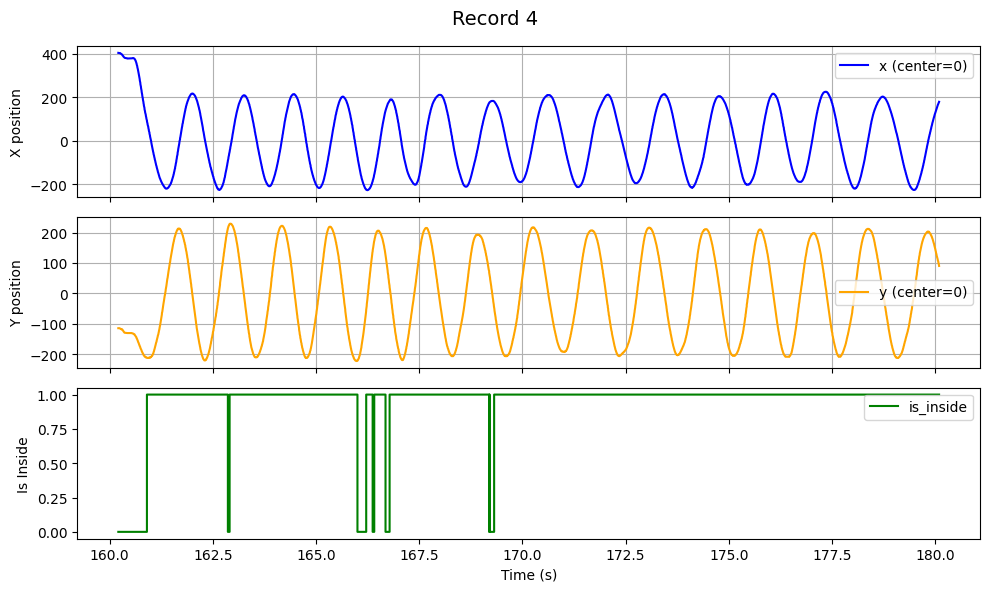


recomputed statistics for all records:
   Var    , nLaps ,       Re ,       Te ,   error ,  MT/lap , IDe/lap ,       Be ,     IPe ,
  unit   ,   lap ,    pixel ,    pixel ,       % ,   s/lap , bit/lap ,   double ,   bit/s ,
Theory  ,  1.00 ,   209.50 ,    47.00 ,    3.88 ,         ,         ,     1.00 ,         ,
Rec001  , -10.84 ,   213.86 ,    91.80 ,    3.89 ,    1.84 ,   14.64 ,     1.95 ,    7.94 ,
Rec002  , -11.97 ,   209.85 ,    34.46 ,    0.73 ,    1.59 ,   38.27 ,     0.73 ,   24.04 ,
Rec003  , -13.26 ,   209.43 ,    42.42 ,    2.81 ,    1.45 ,   31.02 ,     0.90 ,   21.40 ,
Rec004  , -12.83 ,   209.46 ,    37.14 ,    0.13 ,    1.49 ,   35.43 ,     0.79 ,   23.72 ,
Rec005  , -14.74 ,   210.89 ,    43.88 ,    2.83 ,    1.30 ,   30.20 ,     0.93 ,   23.20 ,


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# 1. Code Denis.Mottet (de la documentation mouseReMoCo)
def read_markers(fname):
    markers_dict = {
        "time_stamp": np.array([], dtype=float),
        "label": np.array([], dtype=str),
        "fname": fname,
    }

    def add_marker(time_stamp, label):
        markers_dict["time_stamp"] = np.append(markers_dict["time_stamp"], time_stamp)
        markers_dict["label"] = np.append(markers_dict["label"], label)

    def add_multiline_marker(multiline_time_stamp, multiline_label):
        if multiline_label.endswith("\n"):
            multiline_label = multiline_label[:-1]
        add_marker(multiline_time_stamp, multiline_label)

    with open(fname, "r") as f:
        for line in f:
            if line.strip() == "":
                break

        multiline_mode = False
        multiline_label = ""
        multiline_time_stamp = np.nan

        for line in f:
            if multiline_mode:
                if line.strip() == "":
                    add_multiline_marker(multiline_time_stamp, multiline_label)
                    multiline_mode = False
                else:
                    multiline_label += line
                continue

            items = line.strip().split(",")
            time_stamp = float(items[1])
            label = items[2]
            if label == "":
                multiline_time_stamp = time_stamp
                multiline_label = ""
                multiline_mode = True
            else:
                add_marker(time_stamp, label)

        if multiline_mode:
            add_multiline_marker(multiline_time_stamp, multiline_label)

    return markers_dict

# -----------------------------
# 2. Lecture des données CSV
# -----------------------------
fname_csv = "../data/001MoDe_R1.csv"
fname_marker = "../data/001MoDe_R1.marker.csv"

def is_numeric_line(line):
    try:
        [float(x) for x in line.strip().split(",")]
        return True
    except:
        return False

with open(fname_csv, "r") as f:
    rows = [line for line in f if is_numeric_line(line)]

data = np.loadtxt(StringIO("".join(rows)), delimiter=",")

time_ms = data[:, 0]
x = data[:, 1]
y = data[:, 2]
is_inside_csv = data[:, 3].astype(bool)

# -----------------------------
# 3. Lecture des markers
# -----------------------------
markers = read_markers(fname_marker)
do_record_times = markers["time_stamp"][np.char.startswith(markers["label"], "DoCycleChange:DoRecord")]
t0 = do_record_times[0]

# Temps relatif en secondes
time = (time_ms - t0) / 1000.0

# -----------------------------
# 4. Paramètres de la tâche
# -----------------------------
centerX, centerY = 552.0, 330.0
taskRadius, taskTolerance = 209.5, 47.0

# Recentrer le repère
x_centered = x - centerX
y_centered = y - centerY
dist = np.sqrt(x_centered**2 + y_centered**2)

# -----------------------------
# 5. Intervalles des records
# -----------------------------
record_intervals = [
    (0.022, 20.004),
    (40.429, 60.018),
    (80.371, 100.050),
    (120.608, 140.069),
    (160.146, 180.098)
]

# -----------------------------
# 6. Tracer les graphes pour chaque record
# -----------------------------
for i, (start, end) in enumerate(record_intervals):
    mask = (time >= start) & (time <= end)
    t = time[mask]
    x_rec = x_centered[mask]
    y_rec = y_centered[mask]
    inside_rec = is_inside_csv[mask].astype(int)

    print(f"Record {i} → {mask.sum()} points")

    fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f"Record {i}", fontsize=14)

    axs[0].plot(t, x_rec, 'b-', label='x (center=0)')
    axs[0].set_ylabel("X position")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(t, -y_rec, 'orange', label='y (center=0)')
    axs[1].set_ylabel("Y position")
    axs[1].legend()
    axs[1].grid(True)

    axs[2].step(t, inside_rec, where='post', color='green', label='is_inside')
    axs[2].set_ylabel("Is Inside")
    axs[2].set_xlabel("Time (s)")
    axs[2].legend()

    plt.tight_layout()
    plt.show()

# -----------------------------
# 7. Calcul des métriques et affichage du tableau
# -----------------------------
print("\nrecomputed statistics for all records:")
print(f"   {'Var':<6} , {'nLaps':>5} , {'Re':>8} , {'Te':>8} , {'error':>7} , {'MT/lap':>7} , {'IDe/lap':>7} , {'Be':>8} , {'IPe':>7} ,")
print(f"  {'unit':<6} , {'lap':>5} , {'pixel':>8} , {'pixel':>8} , {'%':>7} , {'s/lap':>7} , {'bit/lap':>7} , {'double':>8} , {'bit/s':>7} ,")
print(f"{'Theory':<7} , {1.00:5.2f} , {209.50:8.2f} , {47.00:8.2f} , {3.88:7.2f} , {'':>7} , {'':>7} , {1.00:8.2f} , {'':>7} ,")

for i, (start, end) in enumerate(record_intervals):
    mask = (time >= start) & (time <= end)
    
    # Extraire tous les points de l'intervalle
    t_all = time[mask]
    x_all = x_centered[mask]
    y_all = y_centered[mask]
    dist_all = dist[mask]
    is_inside_all = is_inside_csv[mask]
    
    if len(t_all) == 0:
        print(f"{'Rec' + str(i+1).zfill(3):<7} , {0:5.2f} , {0:8.2f} , {0:8.2f} , {np.nan:7.2f} , {np.nan:7.2f} , {np.nan:7.2f} , {0:8.2f} , {0:7.2f} ,")
        continue
    
    # --- Step 1: Filter data to start from first entry into target ---
    # According to mouseReMoCo documentation: "statistics are computed only during Record phases 
    # and only after the cursor has entered the target for the first time"
    # This ensures we measure performance only after the user has successfully engaged with the task
    first_inside_indices = np.where(is_inside_all)[0]
    if len(first_inside_indices) > 0:
        first_inside_idx = first_inside_indices[0]
        # Keep only data points after first target entry
        t_all = t_all[first_inside_idx:]
        x_all = x_all[first_inside_idx:]
        y_all = y_all[first_inside_idx:]
        dist_all = dist_all[first_inside_idx:]
        is_inside_all = is_inside_all[first_inside_idx:]
    
    # --- Step 2: Calculate Re (effective radius) ---
    # Re = mean radial distance from center during the task
    # This represents the actual average radius at which the user performed the circular motion
    # Compared to the theoretical taskRadius (209.5 pixels)
    Re = np.mean(dist_all)
    
    # --- Step 3: Calculate Te (effective tolerance) ---
    # Te = 4.1326 × standard deviation of radial distance
    # This constant (4.1326) was empirically determined from mouseReMoCo output
    # Te represents the effective width of the tolerance band achieved by the user
    # A larger Te indicates more variable/less precise circular motion
    # ddof=1 for sample standard deviation (Bessel's correction)
    Te = 4.1326 * np.std(dist_all, ddof=1)
    
    # --- Step 4: Calculate error (percentage of angular displacement outside target) ---
    # error = percentage of phase angle (laps) where cursor was OUTSIDE the target band
    
    # Compute angular position for each point using atan2
    # theta is the angle in radians from center, ranging from -π to π
    theta = np.arctan2(y_all, x_all)
    
    # Compute angular displacement between consecutive points
    # dtheta represents how much the angle changed between samples
    dtheta = np.diff(theta)
    # Unwrap phase: handle discontinuities at ±π boundary
    # (e.g., going from +π to -π should be a small positive change, not -2π)
    dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi
    abs_dtheta = np.abs(dtheta)  # Absolute angular displacement
    
    # Determine which segments were outside the target
    # Use the state at the START of each segment (first point of pair)
    is_outside = ~is_inside_all[:-1]
    
    # Calculate error as weighted by angular displacement:
    # error = (total angle traversed while outside) / (total angle traversed) × 100
    # This gives the percentage of the circular path that was performed outside the target
    total_angle = np.sum(abs_dtheta)
    outside_angle = np.sum(abs_dtheta[is_outside])
    error = (outside_angle / total_angle * 100) if total_angle > 0 else 0
    
    # --- Step 5: Calculate nLaps (number of laps completed) ---
    # Use signed angular displacement to determine direction and count laps
    # Sum of all angular changes divided by 2π gives the number of complete circles
    # Note: negative nLaps indicates counter-clockwise rotation
    # Sign inversion is needed because Java coordinates have Y increasing downward
    signed_angle = np.sum(dtheta)
    nLaps = -signed_angle / (2 * np.pi)
    
    # --- Step 6: Calculate MT (Movement Time per lap) ---
    # MT = total duration / number of laps
    # This gives the average time (in seconds) to complete one full circular motion
    # A lower MT indicates faster performance
    duration = t_all[-1] - t_all[0]
    MT = duration / abs(nLaps) if nLaps != 0 else np.nan
    
    # --- Step 7: Calculate IDe/lap (effective Index of Difficulty per lap) ---
    # IDe = (2π × Re) / Te
    # This is the ratio of distance per lap (circumference at effective radius) to effective tolerance
    # IMPORTANT: This is NOT log2() - it's the direct ratio
    # From Steering Law: ID quantifies task difficulty as the ratio of path length to width
    # Higher IDe means more difficult task (longer path relative to tolerance width)
    IDe = (2 * np.pi * Re) / Te if Te > 0 else np.nan
    
    # --- Step 8: Calculate Be (effective bias ratio) ---
    # Be = Te / taskTolerance
    # This ratio compares the effective tolerance achieved by the user
    # to the theoretical tolerance defined by the task parameters
    # Be = 1.0 means user performance exactly matches task requirements
    # Be > 1.0 means user had more variability than task tolerance (wider effective band)
    # Be < 1.0 means user was more precise than required (narrower effective band)
    Be = Te / taskTolerance
    
    # --- Step 9: Calculate IPe (effective Index of Performance) ---
    # IPe = IDe / MT
    # This represents the throughput or performance efficiency
    # Units: (distance/tolerance) / (seconds/lap) = performance per second
    # Higher IPe indicates better performance (completing more difficult task in less time)
    # Related to Fitts' Law throughput concept
    IPe = IDe / MT if (MT > 0 and not np.isnan(MT)) else np.nan
    
    print(f"{'Rec' + str(i+1).zfill(3):<7} , {nLaps:5.2f} , {Re:8.2f} , {Te:8.2f} , {error:7.2f} , {MT:7.2f} , {IDe:7.2f} , {Be:8.2f} , {IPe:7.2f} ,")